In [2]:
%run setup_matplotlib.ipynb

In [3]:
import numpy as np

QINV = 62209
KYBER_Q = 3329

def get_int16(t, lsb_idx):
    return int.from_bytes([t[lsb_idx], t[lsb_idx+1]], byteorder='little', signed=True)

def montgomery_reduce(a: int) -> int:
    a16 = np.int16(a & 0xFFFF) if a < 0 else np.int16(a % 2**16)
    t16 = np.int16(np.int32(a16) * QINV)
    u = np.int32(a) - np.int32(t16) * KYBER_Q
    return int(u >> 16)

def smlad(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo + np.int32(a_hi) * b_hi)

def smlsd(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo - np.int32(a_hi) * b_hi)

def HW_int32(x: np.int32) -> int:
    x = np.int32(x)
    u = x.view(np.uint32)
    return int(u).bit_count()

In [2]:
print(HW_int32(np.int32(-1)))
print(HW_int32(np.int32(1)))
print(HW_int32(np.int32(-2)))
print(HW_int32(np.int32(2)))


32
1
31
1


In [3]:
from tqdm import tqdm
import numpy as np

import warnings
warnings.filterwarnings('ignore')

for i in tqdm(range(500000)): # Test all cases
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, b0, b1 = vals[:6]
    r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]

    
    zeta = np.int16(-1044) 
    b_zeta = montgomery_reduce(np.int32(zeta) * b1)
    
    acc0 = smlad(s0_0, r0, b0, r1) + smlad(s1_0, r2, b_zeta, r3)
    acc1 = smlad(s0_1, -r0, b0, r1) + smlad(s1_1, -r2, b_zeta, r3)
    acc_sum1 = acc0 + acc1
        
    acc2 = smlad(s0_0, r4, b1, r5) + smlad(s1_0, r6, b0, r7)
    acc3 = smlad(s0_1, -r4, b1, r5) + smlad(s1_1, -r6, b0, r7)
    acc_sum = acc2 + acc3

    assert( montgomery_reduce(acc0) == get_int16(res, 0) )
    assert( montgomery_reduce(acc1) == get_int16(res, 2) )
    assert( montgomery_reduce(acc2) == get_int16(res, 4) )
    assert( montgomery_reduce(acc3) == get_int16(res, 6) )

100%|████████████████████████████████████████████████████████████| 500000/500000 [02:04<00:00, 4001.24it/s]


100%|████████████████████████████████████████████████████████████| 500000/500000 [02:15<00:00, 3688.74it/s]


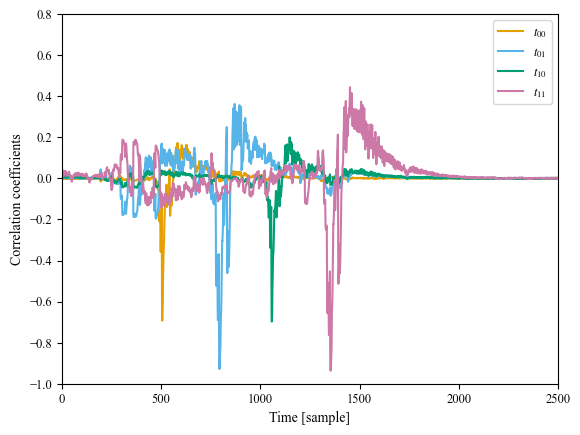

In [39]:
### Check correlations
from scaueclib import OnlineCPA
from tqdm import tqdm
#import matplotlib.pyplot as plt

dim = 5000

onlineVec_acc_0 = OnlineCPA(dim)
onlineVec_acc_1 = OnlineCPA(dim)
onlineVec_acc_2 = OnlineCPA(dim)
onlineVec_acc_3 = OnlineCPA(dim)

isMR = False

N = 500000
for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]
    
    zeta = np.int16(-1044) 
    u_zeta = montgomery_reduce(np.int32(zeta) * u1)
    
    acc_0 = smlad(s0_0, r0, u0, r1) + smlad(s1_0, r2, u_zeta, r3)
    acc_1 = smlad(s0_1, -r0, u0, r1) + smlad(s1_1, -r2, u_zeta, r3)
        
    acc_2 = smlad(s0_0, r4, u1, r5) + smlad(s1_0, r6, u0, r7)
    acc_3 = smlad(s0_1, -r4, u1, r5) + smlad(s1_1, -r6, u0, r7)

    if isMR:
        onlineVec_acc_0.update(trace, HW_int32(montgomery_reduce(acc_0)))
        onlineVec_acc_1.update(trace, HW_int32(montgomery_reduce(acc_1)))
        onlineVec_acc_2.update(trace, HW_int32(montgomery_reduce(acc_2)))
        onlineVec_acc_3.update(trace, HW_int32(montgomery_reduce(acc_3)))
    else:
        onlineVec_acc_0.update(trace, HW_int32(acc_0))
        onlineVec_acc_1.update(trace, HW_int32(acc_1))
        onlineVec_acc_2.update(trace, HW_int32(acc_2))
        onlineVec_acc_3.update(trace, HW_int32(acc_3))
        
pearson_corr_acc0 = onlineVec_acc_0.get_pearson_corr()
pearson_corr_acc1 = onlineVec_acc_1.get_pearson_corr()
pearson_corr_acc2 = onlineVec_acc_2.get_pearson_corr()
pearson_corr_acc3 = onlineVec_acc_3.get_pearson_corr()

if isMR:
    plt.plot(pearson_corr_acc0, label=r"$\text{MR}(t_{00})$")
    plt.plot(pearson_corr_acc1, label=r"$\text{MR}(t_{01})$")
    plt.plot(pearson_corr_acc2, label=r"$\text{MR}(t_{10})$")
    plt.plot(pearson_corr_acc3, label=r"$\text{MR}(t_{11})$")
else:
    plt.plot(pearson_corr_acc0, label=r"$t_{00}$")
    plt.plot(pearson_corr_acc1, label=r"$t_{01}$")
    plt.plot(pearson_corr_acc2, label=r"$t_{10}$")
    plt.plot(pearson_corr_acc3, label=r"$t_{11}$")

plt.legend()

plt.xlim(0, 2500)
plt.ylim(-1.0, 0.8)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

if isMR:
    plt.savefig("images/acc_mr_correlations.pdf", bbox_inches='tight')
else:
    plt.savefig("images/acc_correlations.pdf", bbox_inches='tight')
    
plt.show()

idx_acc0_argmin = np.argmin(pearson_corr_acc0)
idx_acc1_argmin = np.argmin(pearson_corr_acc1)
idx_acc2_argmin = np.argmin(pearson_corr_acc2)
idx_acc3_argmin = np.argmin(pearson_corr_acc3)


In [40]:
!pdfcrop images/acc_correlations.pdf;
!pdfcrop images/acc_mr_correlations.pdf;

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/acc_correlations-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/acc_mr_correlations-crop.pdf'.


In [41]:
print(idx_acc0_argmin, idx_acc1_argmin, idx_acc2_argmin, idx_acc3_argmin)

diff_1_0 = (idx_acc1_argmin - idx_acc0_argmin)
diff_2_1 = (idx_acc2_argmin - idx_acc1_argmin)
diff_3_2 = (idx_acc3_argmin - idx_acc2_argmin)

print(diff_1_0 / 8)
print(diff_2_1 / 8)
print(diff_3_2 / 8)


506 794 1058 1354
36.0
33.0
37.0


In [20]:
### Check correlations
from scaueclib import OnlineCPA
from tqdm import tqdm
import numpy as np

dim = 2500

onlineVec_s00u0_r0r1 = OnlineCPA(dim)
onlineVec_s10uzeta_r2r3 = OnlineCPA(dim)

onlineVec_s01u0_r0r1 = OnlineCPA(dim)
onlineVec_s11uzeta_r2r3 = OnlineCPA(dim)

onlineVec_s00u1_r4r5 = OnlineCPA(dim)
onlineVec_s10u0_r6r7 = OnlineCPA(dim)

onlineVec_s01u1_r4r5 = OnlineCPA(dim)
onlineVec_s11u0_r6r7 = OnlineCPA(dim)


N = 500000
for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]
    
    zeta = np.int16(-1044) 
    u_zeta = montgomery_reduce(np.int32(zeta) * u1)
    
    onlineVec_s00u0_r0r1.update(trace,    HW_int32( smlad(s0_0, r0,  u0,     r1)) )
    onlineVec_s10uzeta_r2r3.update(trace, HW_int32( smlad(s1_0, r2,  u_zeta, r3)) )

    onlineVec_s01u0_r0r1.update(trace,    HW_int32( smlad(s0_1, -r0, u0,     r1)) )
    onlineVec_s11uzeta_r2r3.update(trace, HW_int32( smlad(s1_1, -r2, u_zeta, r3)) )

    onlineVec_s00u1_r4r5.update(trace,    HW_int32( smlad(s0_0, r4,  u1,     r5)) )
    onlineVec_s10u0_r6r7.update(trace,    HW_int32( smlad(s1_0, r6,  u0,     r7)) )

    onlineVec_s01u1_r4r5.update(trace,    HW_int32( smlad(s0_1, -r4, u1,     r5)) )
    onlineVec_s11u0_r6r7.update(trace,    HW_int32( smlad(s1_1, -r6, u0,     r7)) )
    

100%|████████████████████████████████████████████████████████████| 500000/500000 [02:10<00:00, 3826.32it/s]


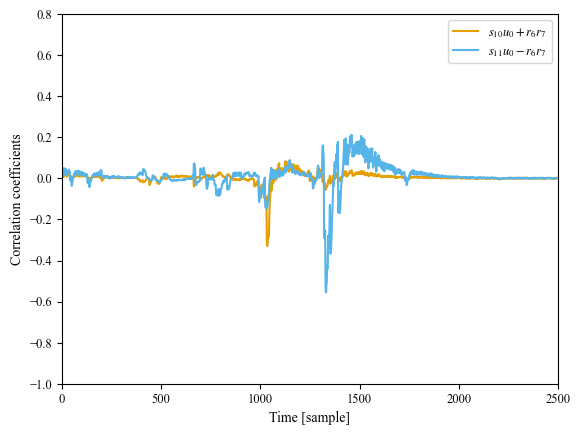

In [25]:
### Plot 


#plt.plot(onlineVec_s00u0_r0r1.get_pearson_corr(), label=r"$s_{00}u_{0} + r_{0}r_{1}$")
#plt.plot(onlineVec_s10uzeta_r2r3.get_pearson_corr(), label=r"$s_{10}u_{1}\zeta + r_{2}r_{3}$")

#plt.plot(onlineVec_s01u0_r0r1.get_pearson_corr(), label=r"$s_{01}u_{0} - r_{0}r_{1}$")
#plt.plot(onlineVec_s11uzeta_r2r3.get_pearson_corr(), label=r"$s_{11}u_{1}\zeta - r_{2}r_{3}$")

#plt.plot(onlineVec_s00u1_r4r5.get_pearson_corr(), label=r"$s_{00}u_{1} + r_{4}r_{5}$")
plt.plot(onlineVec_s10u0_r6r7.get_pearson_corr(), label=r"$s_{10}u_{0} + r_{6}r_{7}$")

#plt.plot(onlineVec_s01u1_r4r5.get_pearson_corr(), label=r"$s_{01}u_{1} - r_{4}r_{5}$")
plt.plot(onlineVec_s11u0_r6r7.get_pearson_corr(), label=r"$s_{11}u_{0} - r_{6}r_{7}$")


plt.legend()

plt.xlim(0, 2500)
plt.ylim(-1.0, 0.8)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

plt.savefig("images/s1u0_correlations.pdf", bbox_inches='tight')

plt.show()

In [26]:
!pdfcrop images/s1u0_correlations.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/s1u0_correlations-crop.pdf'.


In [6]:
### Check correlations without knowledge of randomness
from scaueclib import OnlineCPA
from tqdm import tqdm

dim = 5000

onlineVec_s00u0 = OnlineCPA(dim)
onlineVec_s10uzeta = OnlineCPA(dim)

onlineVec_s01u0 = OnlineCPA(dim)
onlineVec_s11uzeta = OnlineCPA(dim)

onlineVec_s00u1 = OnlineCPA(dim)
onlineVec_s10u0 = OnlineCPA(dim)

onlineVec_s01u1 = OnlineCPA(dim)
onlineVec_s11u0 = OnlineCPA(dim)


N = 500000
for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    #r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]
    r0, r1, r2, r3, r4, r5, r6, r7 = [0, 0, 0, 0, 0, 0, 0, 0] 

    zeta = np.int16(-1044) 
    u_zeta = montgomery_reduce(np.int32(zeta) * u1)
    
    #acc_0 = smlad(s0_0, r0, u0, r1) + smlad(s1_0, r2, u_zeta, r3)
    #acc_1 = smlad(s0_1, -r0, u0, r1) + smlad(s1_1, -r2, u_zeta, r3)
        
    #acc_2 = smlad(s0_0, r4, u1, r5) + smlad(s1_0, r6, u0, r7)
    #acc_3 = smlad(s0_1, -r4, u1, r5) + smlad(s1_1, -r6, u0, r7)


    onlineVec_s00u0.update(trace,    HW_int32( smlad(s0_0, r0,  u0,     r1) ))
    onlineVec_s10uzeta.update(trace, HW_int32( smlad(s1_0, r2,  u_zeta, r3) ))
    
    onlineVec_s01u0.update(trace,    HW_int32( smlad(s0_1, -r0, u0,     r1) ))
    onlineVec_s11uzeta.update(trace, HW_int32( smlad(s1_1, -r2, u_zeta, r3) ))

    onlineVec_s00u1.update(trace,    HW_int32( smlad(s0_0, r4,  u1,     r5) ))
    onlineVec_s10u0.update(trace,    HW_int32( smlad(s1_0, r6,  u0,     r7) ))

    onlineVec_s01u1.update(trace,    HW_int32( smlad(s0_1, -r4, u1,     r5) ))
    onlineVec_s11u0.update(trace,    HW_int32( smlad(s1_1, -r6, u0,     r7) ))
    

100%|████████████████████████████████████████████████████████████| 500000/500000 [02:17<00:00, 3626.30it/s]


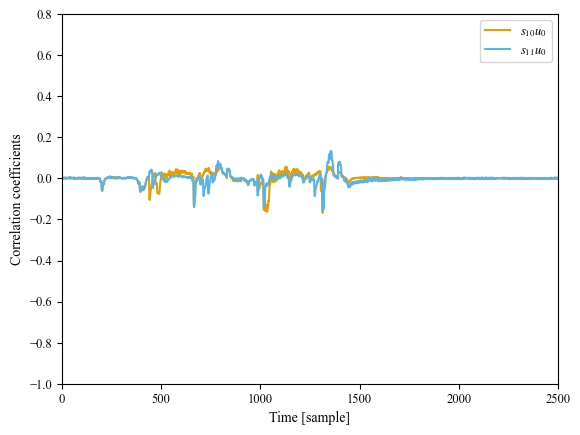

Without knowledge of randomness


In [27]:
### Plot no randomness

#plt.plot(onlineVec_s00u0.get_pearson_corr(), label=r"$s_{00}u_{0}$")
#plt.plot(onlineVec_s10uzeta.get_pearson_corr(), label=r"$s_{10}u_{1}\zeta$")

#plt.plot(onlineVec_s01u0.get_pearson_corr(), label=r"$s_{01}u_{0}$")
#plt.plot(onlineVec_s11uzeta.get_pearson_corr(), label=r"$s_{11}u_{1}\zeta$")

#plt.plot(onlineVec_s00u1.get_pearson_corr(), label=r"$s_{00}u_{1}$")
plt.plot(onlineVec_s10u0.get_pearson_corr(), label=r"$s_{10}u_{0}$")

#plt.plot(onlineVec_s01u1.get_pearson_corr(), label=r"$s_{01}u_{1}$")
plt.plot(onlineVec_s11u0.get_pearson_corr(), label=r"$s_{11}u_{0}$")

plt.legend()

plt.xlim(0, 2500)
plt.ylim(-1.0, 0.8)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

plt.savefig("images/s1u0_wo_rand_knowldge_correlations.pdf", bbox_inches='tight')
plt.show()

print("Without knowledge of randomness")

In [28]:
!pdfcrop images/s1u0_wo_rand_knowldge_correlations.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/s1u0_wo_rand_knowldge_correlations-crop.pdf'.


In [5]:
### Check correlations with random secret-value
from scaueclib import OnlineCPA
from tqdm import tqdm
import numpy as np
np.random.seed(0)

dim = 5000

onlineVec_s00u0_r0r1_randsecret = OnlineCPA(dim)
onlineVec_s10uzeta_r2r3_randsecret = OnlineCPA(dim)

onlineVec_s01u0_r0r1_randsecret = OnlineCPA(dim)
onlineVec_s11uzeta_r2r3_randsecret = OnlineCPA(dim)

onlineVec_s00u1_r4r5_randsecret = OnlineCPA(dim)
onlineVec_s10u0_r6r7_randsecret = OnlineCPA(dim)

onlineVec_s01u1_r4r5_randsecret = OnlineCPA(dim)
onlineVec_s11u0_r6r7_randsecret = OnlineCPA(dim)


N = 500000
for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    #r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]

    r0, r1, r2, r3, r4, r5, r6, r7 = [0, 0, 0, 0, 0, 0, 0, 0] 
    s0_0, s0_1, s1_0, s1_1 = np.random.randint(0, KYBER_Q, 4)
    
    
    zeta = np.int16(-1044) 
    u_zeta = montgomery_reduce(np.int32(zeta) * u1)
    
    #acc_0 = smlad(s0_0, r0, u0, r1) + smlad(s1_0, r2, u_zeta, r3)
    #acc_1 = smlad(s0_1, -r0, u0, r1) + smlad(s1_1, -r2, u_zeta, r3)
        
    #acc_2 = smlad(s0_0, r4, u1, r5) + smlad(s1_0, r6, u0, r7)
    #acc_3 = smlad(s0_1, -r4, u1, r5) + smlad(s1_1, -r6, u0, r7)


    onlineVec_s00u0_r0r1_randsecret.update(trace,    HW_int32( smlad(s0_0, r0,  u0,     r1)) )
    onlineVec_s10uzeta_r2r3_randsecret.update(trace, HW_int32( smlad(s1_0, r2,  u_zeta, r3) ))
    
    onlineVec_s01u0_r0r1_randsecret.update(trace,    HW_int32( smlad(s0_1, -r0, u0,     r1) ))
    onlineVec_s11uzeta_r2r3_randsecret.update(trace, HW_int32( smlad(s1_1, -r2, u_zeta, r3) ))

    onlineVec_s00u1_r4r5_randsecret.update(trace,    HW_int32( smlad(s0_0, r4,  u1,     r5) ) )
    onlineVec_s10u0_r6r7_randsecret.update(trace,    HW_int32( smlad(s1_0, r6,  u0,     r7) ) )

    onlineVec_s01u1_r4r5_randsecret.update(trace,    HW_int32( smlad(s0_1, -r4, u1,     r5) ) )
    onlineVec_s11u0_r6r7_randsecret.update(trace,    HW_int32( smlad(s1_1, -r6, u0,     r7)) )
    

100%|████████████████████████████████████████████████████████████| 500000/500000 [02:14<00:00, 3714.45it/s]


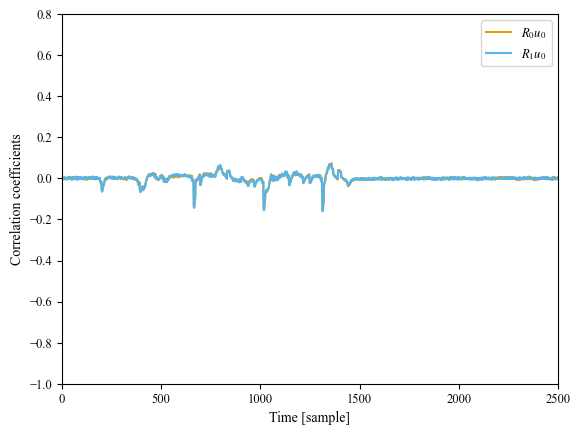

In [13]:
### Plot random secret-value

#plt.plot(onlineVec_s00u0_r0r1_randsecret.get_pearson_corr(), label=r"$s_{00}u_{0}$")
#plt.plot(onlineVec_s10uzeta_r2r3_randsecret.get_pearson_corr(), label=r"$s_{10}u_{1}\zeta$")

#plt.plot(onlineVec_s01u0_r0r1_randsecret.get_pearson_corr(), label=r"$s_{01}u_{0}$")
#plt.plot(onlineVec_s11uzeta_r2r3_randsecret.get_pearson_corr(), label=r"$s_{11}u_{1}\zeta$")

#plt.plot(onlineVec_s00u1_r4r5_randsecret.get_pearson_corr(), label=r"$s_{00}u_{1}$")
plt.plot(onlineVec_s10u0_r6r7_randsecret.get_pearson_corr(), label=r"$R_{0}u_{0}$")

#plt.plot(onlineVec_s01u1_r4r5_randsecret.get_pearson_corr(), label=r"$s_{01}u_{1}$")
plt.plot(onlineVec_s11u0_r6r7_randsecret.get_pearson_corr(), label=r"$R_{1}u_{0}$")

plt.legend()

plt.xlim(0, 2500)
plt.ylim(-1.0, 0.8)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

#plt.savefig("images/acc_correlations.pdf", bbox_inches='tight')

plt.show()

1314
0.0018598042262897019


(1000.0, 1400.0)

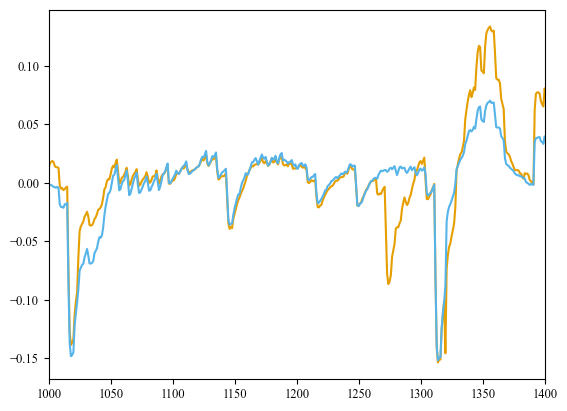

In [19]:

corr_s11u0 = onlineVec_s11u0.get_pearson_corr()
corr_Ru0   = onlineVec_s11u0_r6r7_randsecret.get_pearson_corr()

max_idx = np.argmax(abs(corr_Ru0))
#max_idx = np.argmax(abs(corr_s11u0))
print(max_idx)
print(corr_Ru0[max_idx] - corr_s11u0[max_idx])

plt.plot(corr_s11u0)
plt.plot(corr_Ru0)

plt.xlim(1000, 1400)

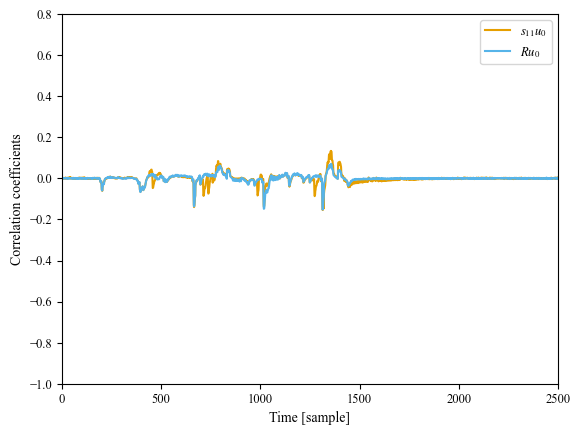

In [30]:

plt.plot(onlineVec_s11u0.get_pearson_corr(), label=r"$s_{11}u_{0}$")

plt.plot(onlineVec_s11u0_r6r7_randsecret.get_pearson_corr(), label=r"$Ru_{0}$")

#plt.plot((onlineVec_s11u0_r6r7_randsecret.get_pearson_corr() - onlineVec_s11u0.get_pearson_corr()), label=r"Diff: $R_{1}u_{0} - s_{11}u_{0}$")


plt.legend()

plt.xlim(0, 2500)
plt.ylim(-1.0, 0.8)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

plt.savefig("images/s1u0_amd_Ru0_corr.pdf", bbox_inches='tight')

plt.show()

In [31]:
!pdfcrop images/s1u0_amd_Ru0_corr.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/s1u0_amd_Ru0_corr-crop.pdf'.
